##1. Import Libraries and Dataset

In [1]:
import pandas as pd

data = pd.read_csv('https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip')

## 2. DF Viewing + Initial Description


In [2]:
data.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


In [3]:
data.describe(include='all')

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
count,951669.000000,951534,951669,947953,834477,951669,951669,951669,951669,951669,951669,951669,951669,951669,951669,9.516690e+05,951669,951669.000000,951669.000000,951669.000000
unique,NaN,10505,5,19339,271,1825,1840,6894,1883,5,3,47,4368,3,7,NaN,3520,NaN,NaN,NaN
top,NaN,London,Europe,75008,Ile-de-France,28FEB2014,28FEB2014,$55.40,$45.60,.,Retail Sale,United States,30JUN1968,Orion Club Gold members,Orion Club Gold members high activity,NaN,($0.20),NaN,NaN,NaN
freq,NaN,47573,653684,4249,74897,1096,967,3301,4435,942517,715970,232258,549,483438,223488,NaN,86795,NaN,NaN,NaN
mean,1.678438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.236943e+09,NaN,1.056107,66.534079,45440.602683
std,0.899914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.273202e+06,NaN,2.065725,46.476795,27214.145206
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.230000e+09,NaN,0.000000,0.000000,1.000000
25%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.233081e+09,NaN,0.000000,0.000000,22139.000000
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.236755e+09,NaN,0.000000,99.000000,44140.000000
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.240689e+09,NaN,1.000000,99.000000,70411.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951669 entries, 0 to 951668
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Quantity              951669 non-null  int64 
 1   City                  951534 non-null  object
 2   Continent             951669 non-null  object
 3   Postal_Code           947953 non-null  object
 4   State_Province        834477 non-null  object
 5   Order_Date            951669 non-null  object
 6   Delivery_Date         951669 non-null  object
 7   Total Revenue         951669 non-null  object
 8   Unit Cost             951669 non-null  object
 9   Discount              951669 non-null  object
 10  OrderTypeLabel        951669 non-null  object
 11  CustomerCountryLabel  951669 non-null  object
 12  Customer_BirthDate    951669 non-null  object
 13  Customer_Group        951669 non-null  object
 14  Customer_Type         951669 non-null  object
 15  Order ID         

In [5]:
data.duplicated().sum()

np.int64(21)

In [6]:
#find missing values
data.isnull().sum()
data.isnull().sum()/len(data)

,0
Quantity,0.000000
City,0.000142
Continent,0.000000
Postal_Code,0.003905
State_Province,0.123144
Order_Date,0.000000
Delivery_Date,0.000000
Total Revenue,0.000000
Unit Cost,0.000000
Discount,0.000000


In [7]:
#aggregate all customer by row (one customer by row)
data['Order_Date'] = pd.to_datetime(data['Order_Date'])
data['Delivery_Date'] = pd.to_datetime(data['Delivery_Date'])
data['Customer_BirthDate'] = pd.to_datetime(data['Customer_BirthDate'])

#clean strings
for col in ['Unit Cost', 'Total Revenue']:
    data[col] = data[col].str.replace(r'[\$,]', '', regex=True).astype(float)

dataAggregated = data.groupby('Customer ID').agg(
    frequency = ('Order ID', 'nunique'),
    lastOrderDate = ('Order_Date', 'max'),
    customerLifetimeValue = ('Total Revenue', 'sum'),
    averageUnitCost = ('Unit Cost', 'mean'),
    customerBirthdate = ('Customer_BirthDate', 'first'),

    continent = ('Continent', 'first'),
    country = ('CustomerCountryLabel', 'first'),
    city = ('City', 'first'),
    postal_code = ('Postal_Code', 'first'),
    state_province = ('State_Province', 'first'),
    order_type_label = ('OrderTypeLabel', 'first'),
    customer_group = ('Customer_Group', 'first'),
    customer_type = ('Customer_Type', 'first'),
    loyalty_number = ('Loyalty Num', 'first'),
).reset_index()

/tmp/ipykernel_6089/4046045846.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Order_Date'] = pd.to_datetime(data['Order_Date'])
/tmp/ipykernel_6089/4046045846.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Delivery_Date'] = pd.to_datetime(data['Delivery_Date'])
/tmp/ipykernel_6089/4046045846.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Customer_BirthDate'] = pd.to_datetime(data['Customer_BirthDate'])


In [8]:
dataAggregated.head()

,Customer ID,frequency,lastOrderDate,customerLifetimeValue,averageUnitCost,customerBirthdate,continent,country,city,postal_code,state_province,order_type_label,customer_group,customer_type,loyalty_number
0,1,28,2016-12-13,4322.70,89.622857,1953-11-24,Europe,France,Paris,75009,Ile-de-France,Retail Sale,Orion Club Gold members,Orion Club Gold members high activity,0
1,3,14,2016-08-28,2821.00,90.505000,1983-07-01,Europe,Italy,Bologna,40128,Emilia-Romagna,Retail Sale,Orion Club members,Orion Club members high activity,99
2,4,8,2013-12-18,782.67,37.195556,1983-06-27,North America,United States,Denver,80210,Colorado,Internet Sale,Orion Club members,Orion Club members low activity,0
3,5,15,2016-12-25,2810.98,107.947368,1988-07-08,North America,United States,South Gate,90280,California,Catalog Sale,Orion Club Gold members,Orion Club Gold members medium activity,99
4,6,13,2016-06-21,1604.58,52.526667,1958-12-23,Europe,Belgium,Genk,3600,None,Retail Sale,Orion Club members,Orion Club members medium activity,99


##3. Feature Engineering

In [9]:
dataEndDate = pd.Timestamp('2016-12-30')

dataAggregated['recency'] = (dataEndDate - dataAggregated['lastOrderDate']).dt.days
dataAggregated['customerAge'] = ((dataEndDate - dataAggregated['customerBirthdate']).dt.days // 365).astype(int)

dataAggregated.drop(columns=['lastOrderDate', 'customerBirthdate'], inplace=True)

dataAggregated.head()

,Customer ID,frequency,customerLifetimeValue,averageUnitCost,continent,country,city,postal_code,state_province,order_type_label,customer_group,customer_type,loyalty_number,recency,customerAge
0,1,28,4322.70,89.622857,Europe,France,Paris,75009,Ile-de-France,Retail Sale,Orion Club Gold members,Orion Club Gold members high activity,0,17,63
1,3,14,2821.00,90.505000,Europe,Italy,Bologna,40128,Emilia-Romagna,Retail Sale,Orion Club members,Orion Club members high activity,99,124,33
2,4,8,782.67,37.195556,North America,United States,Denver,80210,Colorado,Internet Sale,Orion Club members,Orion Club members low activity,0,1108,33
3,5,15,2810.98,107.947368,North America,United States,South Gate,90280,California,Catalog Sale,Orion Club Gold members,Orion Club Gold members medium activity,99,5,28
4,6,13,1604.58,52.526667,Europe,Belgium,Genk,3600,None,Retail Sale,Orion Club members,Orion Club members medium activity,99,192,58


In [10]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

features = ['frequency', 'recency', 'customerLifetimeValue', 'averageUnitCost', 'customerAge']

scaler = StandardScaler()
xScaled = scaler.fit_transform(dataAggregated[features])

dataAggregatedScaled = pd.DataFrame(xScaled, columns=features, index=dataAggregated.index)
dataAggregatedScaled.head()

,frequency,recency,customerLifetimeValue,averageUnitCost,customerAge
0,1.943794,-0.845972,1.379438,0.282284,1.136085
1,0.347624,-0.587834,0.506319,0.305496,-0.579565
2,-0.336449,1.786063,-0.678807,-1.097215,-0.579565
3,0.461636,-0.874922,0.500493,0.764450,-0.865507
4,0.233611,-0.423785,-0.200932,-0.693813,0.850144


All five feature columns are numeric so no encoding is needed

In [11]:
#sanity checks
print(dataAggregatedScaled.describe(include="all"))
print(dataAggregatedScaled.isnull().sum())
print(dataAggregatedScaled.shape)

          frequency       recency  customerLifetimeValue  averageUnitCost  \
count  6.830000e+04  6.830000e+04           6.830000e+04     6.830000e+04   
mean   2.132669e-17  4.993565e-18          -3.466887e-17     2.101459e-16   
std    1.000007e+00  1.000007e+00           1.000007e+00     1.000007e+00   
min   -1.134535e+00 -8.869841e-01          -1.133501e+00    -2.062770e+00   
25%   -6.784859e-01 -7.784217e-01          -7.291988e-01    -5.608524e-01   
50%   -2.224372e-01 -4.286096e-01          -2.632196e-01    -1.432847e-01   
75%    4.616358e-01  4.139553e-01           4.416913e-01     3.583907e-01   
max    1.026668e+01  3.513412e+00           9.832275e+00     3.643257e+01   

        customerAge  
count  6.830000e+04  
mean  -1.332658e-16  
std    1.000007e+00  
min   -1.380202e+00  
25%   -8.655066e-01  
50%   -7.681491e-03  
75%    8.501436e-01  
max    1.765157e+00  
frequency                0
recency                  0
customerLifetimeValue    0
averageUnitCost          0


Description looks reasonable, no null values, and shape looks correct with 68,300 customers and five features. Good to continue.

##4. EDA to explore data visualizations

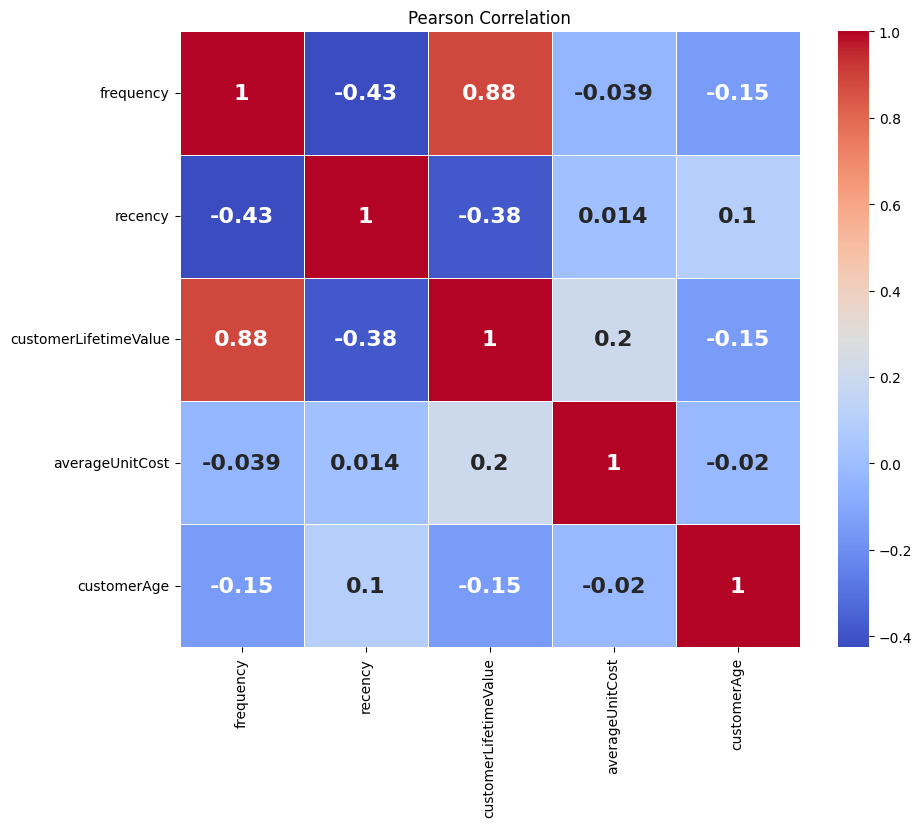

In [12]:
#standard correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corrMatrixPearson = dataAggregatedScaled.corr(method='pearson')
sns.heatmap(corrMatrixPearson,
            annot=True,
            cmap = 'coolwarm',
            linewidths=0.5,
            annot_kws={"fontsize": 16, "fontweight": "bold"})
plt.title('Pearson Correlation')
plt.show()

Since we standardized, we use Pearson. We notice high positive correlation between customerLifetimeValue and frequency, likely because CLV is a function of frequency. This could lead to bias, need to be aware

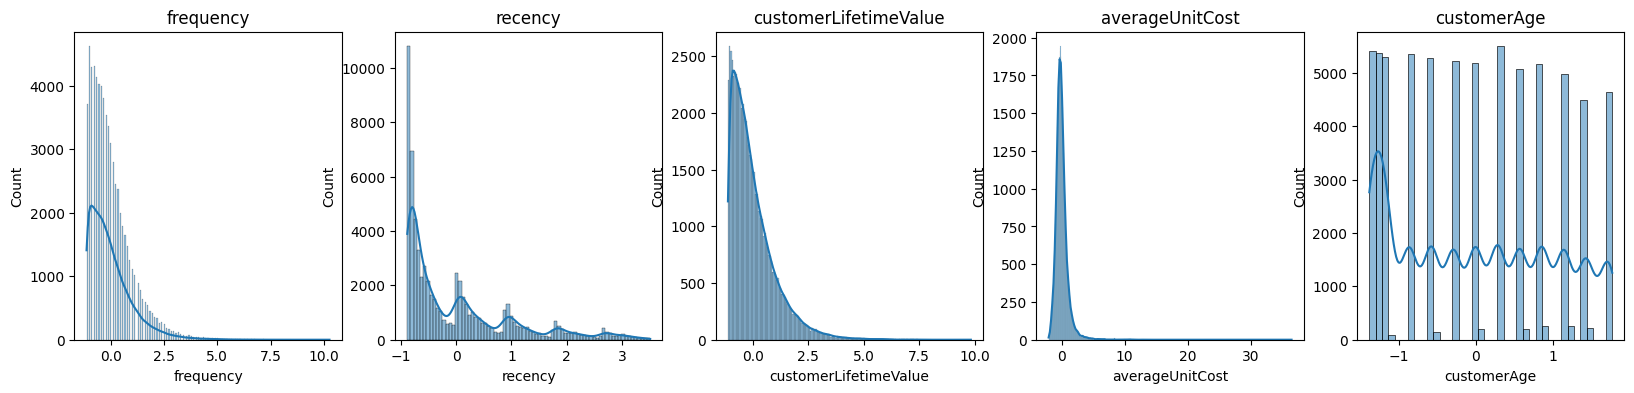

In [13]:
#distribution check
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, col in zip(axes, features):
  sns.histplot(dataAggregatedScaled[col], ax=ax, kde=True)
  ax.set_title(col)
plt.show()

Most data is skewed with outliers that are above the mean. Things to note:
1. recency has many different clusters/peaks
2. customer age is wonky, to be expected since we standardized
3. average unit cost is normal with a high right tail (positive skew)

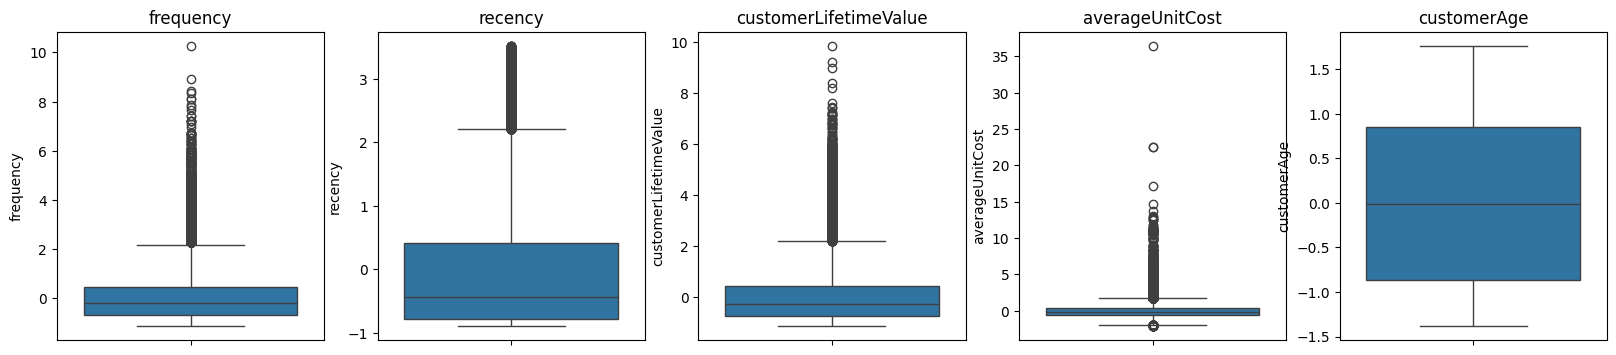

In [14]:
#boxplot outlier check
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, col in zip(axes, features):
  sns.boxplot(dataAggregatedScaled[col], ax=ax)
  ax.set_title(col)
plt.show()

Confirms previous statement.
1. Frequency is highly skewed, so is CLV and AUC
2. Recency seems to be clustered in terms of the variance

Will use z-score method for anomaly detection and removal, since we already scaled the data.

In [15]:
from scipy.stats import zscore

zScores = dataAggregatedScaled.apply(zscore)
zScores

,frequency,recency,customerLifetimeValue,averageUnitCost,customerAge
0,1.943794,-0.845972,1.379438,0.282284,1.136085
1,0.347624,-0.587834,0.506319,0.305496,-0.579565
2,-0.336449,1.786063,-0.678807,-1.097215,-0.579565
3,0.461636,-0.874922,0.500493,0.764450,-0.865507
4,0.233611,-0.423785,-0.200932,-0.693813,0.850144
...,...,...,...,...,...
68295,-0.678486,0.934452,-0.562639,0.377724,-0.579565
68296,-1.020522,1.332514,-0.594437,0.951996,-1.380202
68297,2.513855,-0.768772,4.279893,-0.041640,-0.007681
68298,-0.450462,-0.049847,-0.288947,-0.128794,0.335449


In [16]:
threshold = 3.5

anomalies = zScores[(zScores > threshold) | (zScores < -threshold)].dropna(how='all')

print(anomalies.shape)
anomalies

(1621, 5)


,frequency,recency,customerLifetimeValue,averageUnitCost,customerAge
108,6.732305,NaN,7.233466,NaN,NaN
111,NaN,NaN,5.377922,NaN,NaN
132,NaN,NaN,NaN,4.841657,NaN
166,NaN,NaN,5.744147,NaN,NaN
319,NaN,NaN,NaN,3.748368,NaN
...,...,...,...,...,...
68068,NaN,NaN,NaN,10.727786,NaN
68073,NaN,NaN,NaN,6.428307,NaN
68125,3.653977,NaN,NaN,NaN,NaN
68126,NaN,NaN,NaN,3.904928,NaN


This is about 5% of the entire dataset. That's too much to drop, so will remove only if multiple features are outliers

In [17]:
import numpy as np
threshold = 3

zScores = pd.DataFrame(zscore(dataAggregated[features]), columns=features)

# Only drop if 2 or more features exceed threshold
outlierMask = (np.abs(zScores) > threshold).sum(axis=1) >= 2

dataClean = dataAggregated[~outlierMask].reset_index(drop=True)

print(f"Removed: {outlierMask.sum()} rows ({outlierMask.sum()/len(dataAggregated)*100:.1f}%)")

Removed: 684 rows (1.0%)


This seems much more reasonable

##5 Incorporate Transformer and Pipeline

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['frequency', 'recency', 'customerLifetimeValue', 'averageUnitCost', 'customerAge']

preprocessor = ColumnTransformer(transformers = [
    ('scaler', StandardScaler(), features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

pipeline.fit(dataClean[features])

dataClean['cluster'] = pipeline.named_steps['kmeans'].labels_

##6. Optimal value with Elbor and Silhouette Methods

Elbow method will measure intra-cluster compactness, and silhouette will identify and separate clusters more cleanly.

I plan to first use the Elbow method to determine the candidate k-values, then use the Silhouette to find the optimal number.

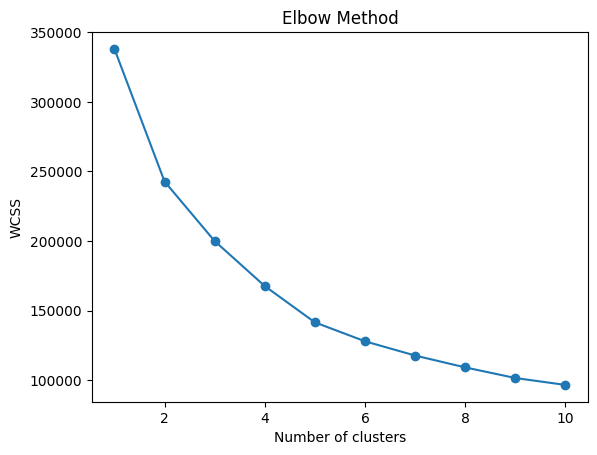

In [19]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

xScaledCleaned = pipeline.named_steps['preprocessor'].transform(dataClean[features])

#elbow method
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  kmeans.fit(xScaledCleaned)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Only run Silhouette for candidate values, otherwise too computationally expensive

In [20]:
from sklearn.metrics import silhouette_score

#random seed to sample first, because too slow on large dataset
np.random.seed(42)
sampleIdx = np.random.choice(len(xScaledCleaned), 5000, replace=False)
xSample = xScaledCleaned[sampleIdx]

for k in [3, 4, 5]:
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=3)
  labels = kmeans.fit(xScaledCleaned).labels_[sampleIdx]
  score = silhouette_score(xSample, labels)
  print(f'Silhouette score for k={k}: {score}')


Silhouette score for k=3: 0.2489139514941682
Silhouette score for k=4: 0.2507095321911391
Silhouette score for k=5: 0.2638988527787475


Run a bit more to see if score trends upwards, it is a bit low right now

In [21]:
for k in [5,6,7]:
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=3)
  labels = kmeans.fit(xScaledCleaned).labels_[sampleIdx]
  score = silhouette_score(xSample, labels)
  print(f'Silhouette score for k={k}: {score}')

Silhouette score for k=5: 0.2638988527787475
Silhouette score for k=6: 0.23559227411096284
Silhouette score for k=7: 0.23010688155384076


The score is maxed at k=5, we will take that to be the optimum k value

##7. Hierarchical clustering and dendogram

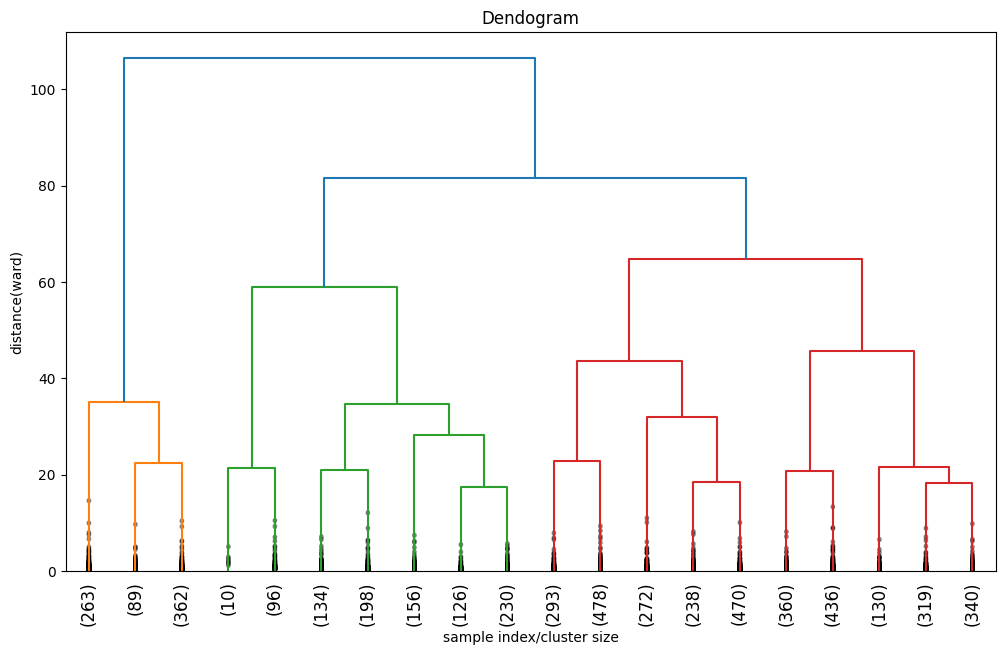

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

np.random.seed(42)
sampleIdx = np.random.choice(len(xScaledCleaned), 5000, replace=False)
xSampleHierarchy = xScaledCleaned[sampleIdx]

linked = linkage(xSampleHierarchy, method='ward') #min variance within clusters

plt.figure(figsize=(12,7))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=12,
    show_contracted=True
)
plt.title('Dendogram')
plt.xlabel('sample index/cluster size')
plt.ylabel('distance(ward)')
plt.show()

The dendrogram shows three main clusters, suggesting k=3. To reconcile, elbow shows 3 or 4, silhouette says 5, and dendrogram says 3. We take the mean and use k=4 instead as the K.

##8. Implement kmeans clustering

We already did most of the steps, but now we run the final one with k=4

In [23]:
kmeansFinal = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
kmeansFinal.fit(xScaledCleaned)

dataClean['cluster'] = kmeansFinal.labels_

dataClean.head()

,Customer ID,frequency,customerLifetimeValue,averageUnitCost,continent,country,city,postal_code,state_province,order_type_label,customer_group,customer_type,loyalty_number,recency,customerAge,cluster
0,1,28,4322.70,89.622857,Europe,France,Paris,75009,Ile-de-France,Retail Sale,Orion Club Gold members,Orion Club Gold members high activity,0,17,63,0
1,3,14,2821.00,90.505000,Europe,Italy,Bologna,40128,Emilia-Romagna,Retail Sale,Orion Club members,Orion Club members high activity,99,124,33,2
2,4,8,782.67,37.195556,North America,United States,Denver,80210,Colorado,Internet Sale,Orion Club members,Orion Club members low activity,0,1108,33,3
3,5,15,2810.98,107.947368,North America,United States,South Gate,90280,California,Catalog Sale,Orion Club Gold members,Orion Club Gold members medium activity,99,5,28,2
4,6,13,1604.58,52.526667,Europe,Belgium,Genk,3600,None,Retail Sale,Orion Club members,Orion Club members medium activity,99,192,58,1


##9. View the Cluster number associated with each customer ID

In [24]:
dataCustomerIDCluster = dataClean[['Customer ID', 'cluster']]

dataCustomerIDCluster.head()

,Customer ID,cluster
0,1,0
1,3,2
2,4,3
3,5,2
4,6,1


In [25]:
print(dataCustomerIDCluster.groupby('cluster').size())

cluster
0    13567
1    20098
2    22525
3    11426
dtype: int64


##10. Boxplots to display clusters with regards to key inputs

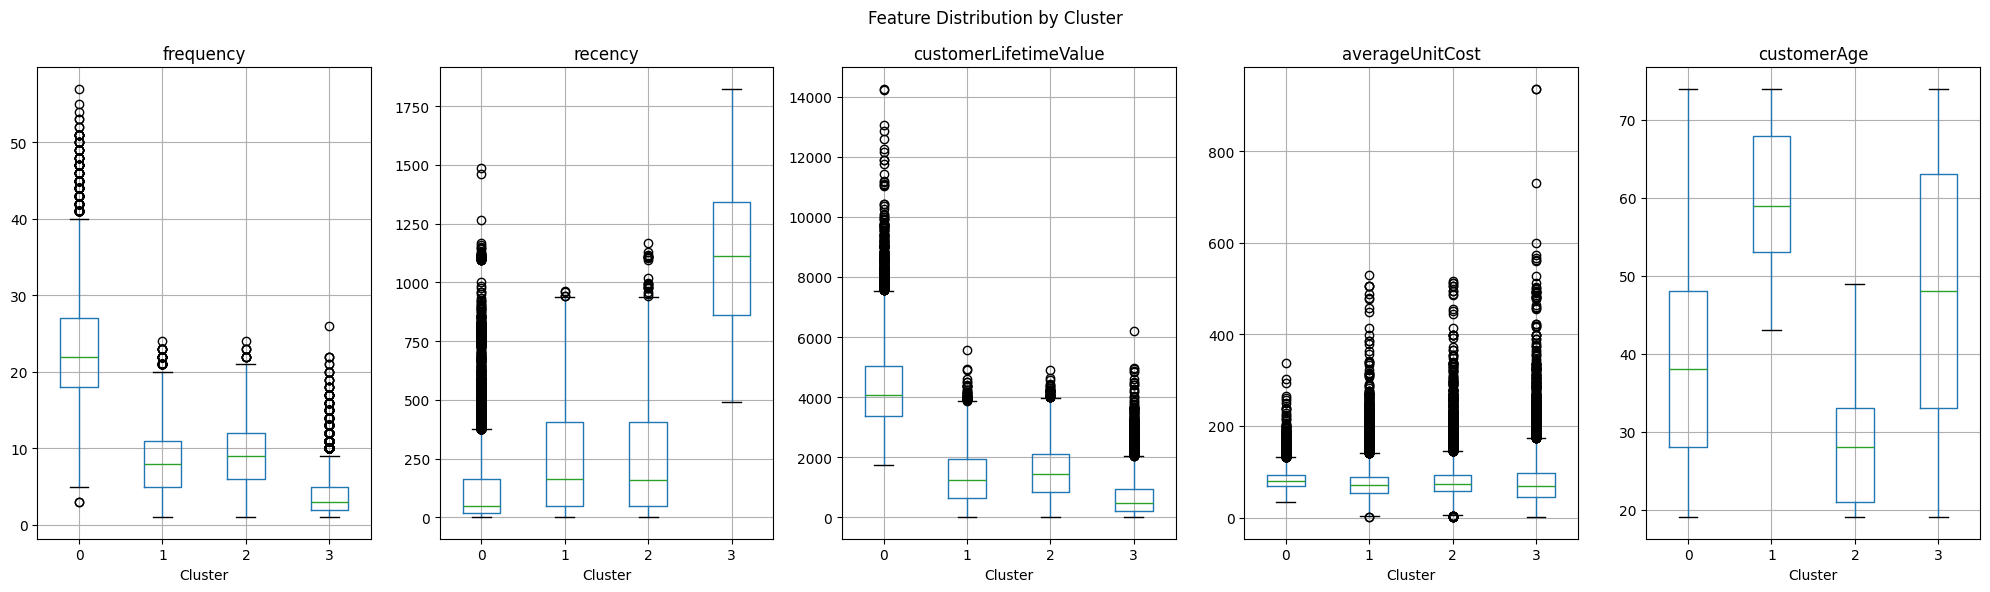

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, col in zip(axes, features):
    dataClean.boxplot(column=col, by='cluster', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Cluster')

plt.suptitle('Feature Distribution by Cluster')
plt.tight_layout()
plt.show()

Thing to note: we are using unscaled data so that there are meaningful values to interpret.

Cluster 0 seem to be our most valuable customers, high frequency, high CLV with higher average UnitCost as a result.

Cluster 1 seem to be our occasional buyers, with low-medium frequency, low CLV but relatively recent purchasing. Engaged but low spend, opportunity to upsell to encourage to spend more.

Cluster 2 is churned or inactive, extremely low frequency but high recency and low CLV. Risk of losing, need to target in marketing campaigns.

Cluster 3 is wobbling, med frequency, high recency and med CLV. Becoming inactive, win-back campaign.

##11. Dimension reduction with PCA and t-SNE

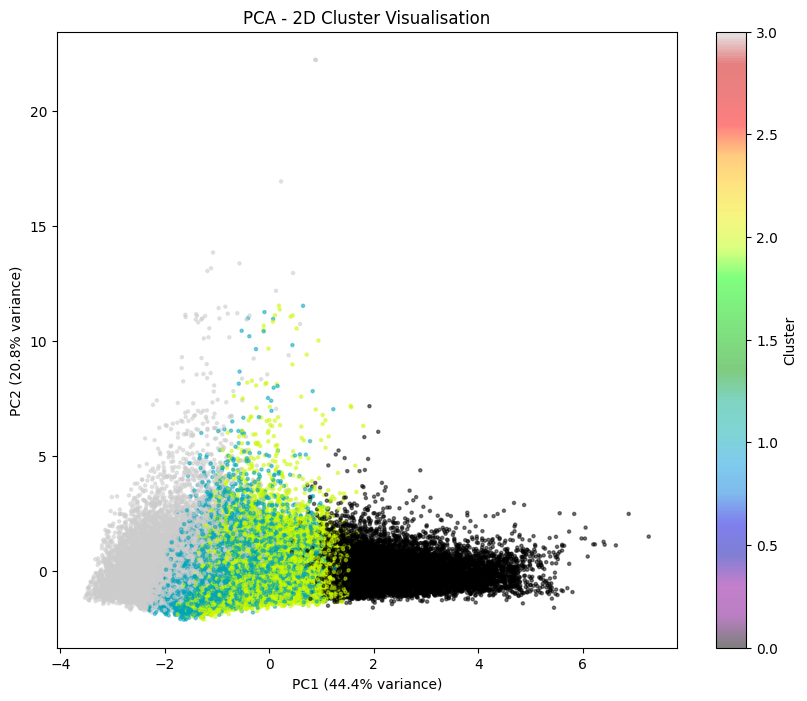

Total variance explained: 65.2%


In [27]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#PCA
pca = PCA(n_components=2)
xPCA = pca.fit_transform(xScaledCleaned)

plt.figure(figsize=(10, 8))
plt.scatter(xPCA[:, 0], xPCA[:, 1], c=dataClean['cluster'], cmap='nipy_spectral', alpha=0.5, s=5)
plt.colorbar(label='Cluster')
plt.title('PCA - 2D Cluster Visualisation')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

The clusters are pretty well defined, with a fairly high amount of variance explained.

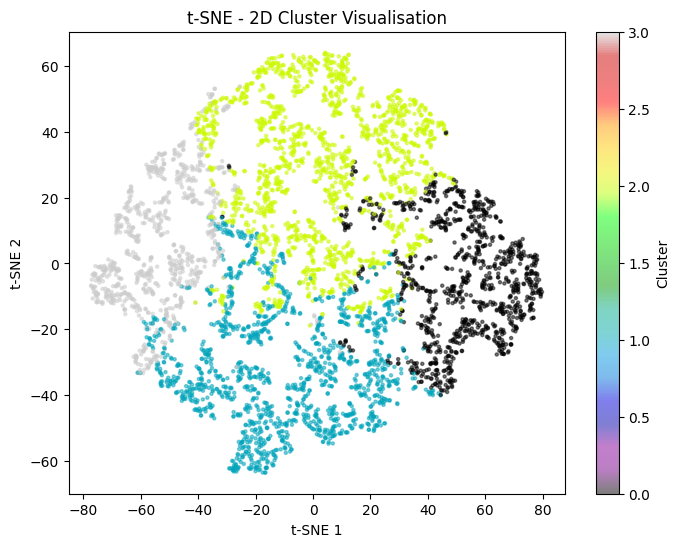

In [28]:
np.random.seed(42) #sample for speed of calculation
sampleIdx = np.random.choice(len(xScaledCleaned), 5000, replace=False)
xSampleTSNE = xScaledCleaned[sampleIdx]
clusterSample = dataClean['cluster'].values[sampleIdx]

xTSNE = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(xSampleTSNE)

plt.figure(figsize=(8, 6))
plt.scatter(xTSNE[:, 0], xTSNE[:, 1], c=clusterSample, cmap='nipy_spectral', alpha=0.5, s=5)
plt.colorbar(label='Cluster')
plt.title('t-SNE - 2D Cluster Visualisation')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

Even clearer defined clusters here

# Reflect

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

> Data Pre-processing

951,668 transactions aggregated to one row per customer using .groupby().agg()
Removed $ and , from currency columns, parsed date columns
Removed missing values and duplicates
Outliers removed where a customer exceeded 3 standard deviations in 2+ features simultaneously

Feature Engineering

5 features derived: frequency, recency, CLV, average unit cost, customer age
ColumnTransformer and Pipeline used to apply StandardScaler to all features

EDA

Frequency, CLV, and average unit cost were right-skewed
Strong correlation (0.88) between frequency and CLV — both retained as per brief
Majority of customers make few low-value purchases

Optimal K

Elbow method → K=3–4
Silhouette scores → K=5 (marginal, scores very close across K=3–5)
Dendrogram → K=3
Consensus across all three → K=4 selected

Cluster Profiles

Cluster 0: high frequency, low recency, high CLV → high value active customers
Cluster 1: medium frequency, low recency, medium CLV → occasional buyers
Cluster 2: low frequency, high recency, low CLV → churned/inactive customers
Cluster 3: medium frequency, high recency, medium CLV → lapsing mid-value customers

Dimensionality Reduction

PCA: fast linear projection, variance explained shown on axes
t-SNE: better visual separation, preserves local cluster structure
t-SNE provided clearer cluster boundaries but is slower — sampled 5,000 rows

### Reference:
SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].